In [1]:
%%capture
!pip install pandas matplotlib numpy

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [35]:
df = pd.read_csv("/content/Crime_Data_from_2020_to_2024.csv")

In [36]:
df.head(2)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203


In [ ]:
# Existem quatro tipos de análise de dados princípais

# Análise Descritiva
# Análise Diagnóstica
# Análise Preditiva
# Análise Presecritica

In [5]:
# A missão do ciêntista de dados é:
#   Extrair conhecimento de dados desorganizados.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

In [7]:
# AGEMC

# Ask
# Get
# Explorer
# Model
# Comunicate

In [ ]:
# Qual o gênero das vítimas?

In [20]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [39]:
genero_vitimas = df["Vict Sex"].value_counts()
genero_vitimas = genero_vitimas.reset_index()

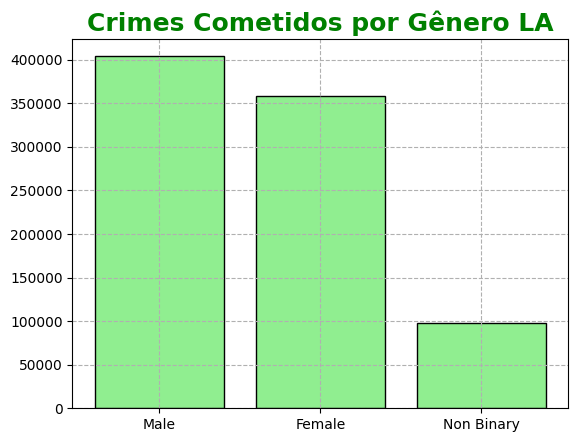

In [40]:
plt.bar(["Male", "Female", "Non Binary"],
        list(genero_vitimas["count"])[:3],
        color= 'lightgreen',
        width= 0.8,
        edgecolor= "black")

plt.grid(True,
         linestyle= '--')


plt.title("Crimes Cometidos por Gênero LA",
          color= "green",
          weight= "bold",
          family= "sans-serif",
          size= 18)

plt.show()



In [11]:
# Quais os crimes mais cometidos?

In [41]:
crimes_mais_comuns = df["Crm Cd Desc"].value_counts()
crimes_mais_comuns = crimes_mais_comuns.reset_index()

In [42]:
crimes_mais_comuns.iloc[10]

,10
Crm Cd Desc,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...
count,36940


In [43]:
crimes_mais_comuns_cd = df["Crm Cd"].value_counts()
crimes_mais_comuns_cd = crimes_mais_comuns_cd.reset_index()

In [44]:
crimes_mais_comuns_cd.head()

,Crm Cd,count
0,510,115184
1,624,74821
2,330,63515
3,354,62536
4,740,61086


In [45]:
df[df["Crm Cd"].isin(list(crimes_mais_comuns_cd["Crm Cd"]))]

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
1004890,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
1004891,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
1004892,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868


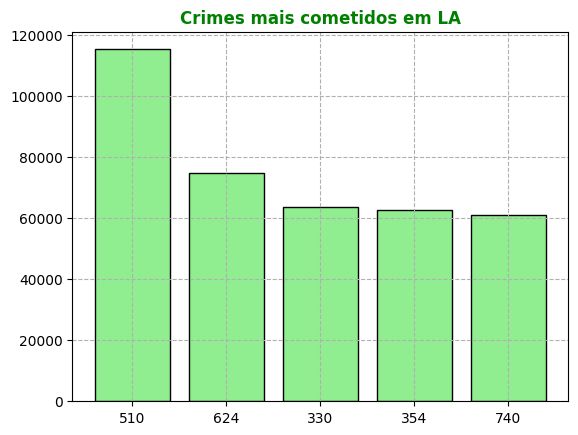

In [46]:
# Os 10 crimes mais comuns em LA

plt.bar([str(numero) for numero in list(crimes_mais_comuns_cd["Crm Cd"])][:5],
        list(crimes_mais_comuns_cd['count'])[:5],
        color= "lightgreen",
        edgecolor= "black")


plt.title("Crimes mais cometidos em LA",
          color= "green",
          weight= "bold")

plt.grid(True, linestyle= '--')

plt.show()

In [48]:
# Qual o gênero das princípais vítimas de roubo de carro, código 510.


roubo_carro = df[df["Crm Cd"] == 510]

# Nesta coluna apenas 597 pontos de dados não são nulos
genero_vitmas_roubo_carro = roubo_carro["Vict Sex"].value_counts()
genero_vitmas_roubo_carro

,count
Vict Sex,
M,341
F,129
X,127


In [49]:
roubo_carro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115184 entries, 12 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           115184 non-null  int64  
 1   Date Rptd       115184 non-null  object 
 2   DATE OCC        115184 non-null  object 
 3   TIME OCC        115184 non-null  int64  
 4   AREA            115184 non-null  int64  
 5   AREA NAME       115184 non-null  object 
 6   Rpt Dist No     115184 non-null  int64  
 7   Part 1-2        115184 non-null  int64  
 8   Crm Cd          115184 non-null  int64  
 9   Crm Cd Desc     115184 non-null  object 
 10  Mocodes         548 non-null     object 
 11  Vict Age        115184 non-null  int64  
 12  Vict Sex        597 non-null     object 
 13  Vict Descent    593 non-null     object 
 14  Premis Cd       115180 non-null  float64
 15  Premis Desc     115180 non-null  object 
 16  Weapon Used Cd  54 non-null      float64
 17  Weapon Desc  

In [50]:
genero_vitmas_roubo_carro.head()

,count
Vict Sex,
M,341
F,129
X,127


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

In [52]:
# Qual a idade das vítimas?

contagem_idade = df["Vict Age"].value_counts().reset_index()

In [53]:
contagem_idade = contagem_idade[(contagem_idade["Vict Age"] > 0) & (contagem_idade["Vict Age"] < 130)]
contagem_idade = contagem_idade.reset_index()

In [54]:
contagem_idade.drop("index", axis= 1)

,Vict Age,count
0,30,22288
1,35,21832
2,31,21419
3,29,21343
4,28,20969
...,...,...
94,95,100
95,96,94
96,97,72
97,98,71


In [55]:
df_idades = df[(df["Vict Age"] > 0) & (df["Vict Age"] < 130)]

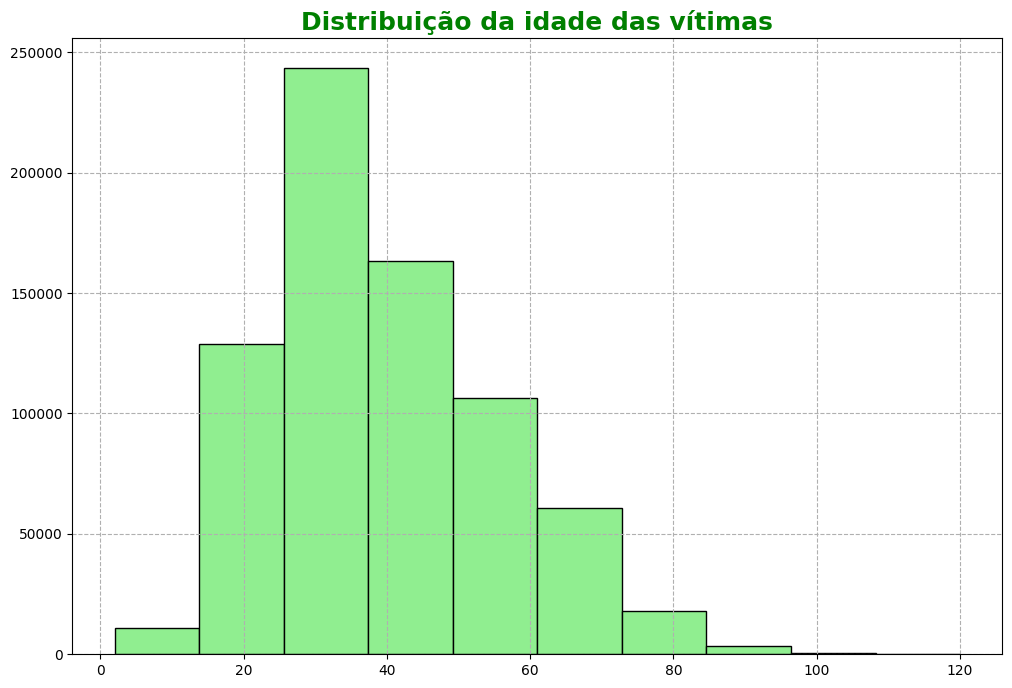

In [56]:
df_idades["Vict Age"].hist(figsize= (12, 8),
                           color= "lightgreen",
                           edgecolor= "black")

plt.title("Distribuição da idade das vítimas",
          size= 18,
          weight= "bold",
          color= "green")

plt.grid(True, linestyle= '--')
plt.show()

In [ ]:
# A maior parte das vítimas tem entre 30 e 50 anos.

In [57]:
contagem_idade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   index     99 non-null     int64
 1   Vict Age  99 non-null     int64
 2   count     99 non-null     int64
dtypes: int64(3)
memory usage: 2.4 KB


In [75]:
# A distribuição das idades das pessoas que sofrem o crime mais cometido

idades_filtradas_a = df[(df["Vict Age"] >= 0) & (df["Vict Age"] < 130)]

In [76]:
idades_filtradas_a

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
1004890,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
1004891,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
1004892,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868


In [81]:
roubo_de_carros = idades_filtradas_a[idades_filtradas_a["Crm Cd"] == 510]

In [82]:
roubo_de_carros

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
12,202113531,09/06/2020 12:00:00 AM,09/05/2020 12:00:00 AM,1500,21,Topanga,2149,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,19700 VANOWEN ST,NaN,34.1938,-118.5631
31,201811813,05/28/2020 12:00:00 AM,05/25/2020 12:00:00 AM,200,18,Southeast,1851,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,MENLO AV,130TH ST,33.9144,-118.2894
39,201416348,08/30/2020 12:00:00 AM,08/28/2020 12:00:00 AM,1200,14,Pacific,1453,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 GLENCOE AV,NaN,33.9918,-118.4446
54,201904694,01/16/2020 12:00:00 AM,01/15/2020 12:00:00 AM,2130,19,Mission,1901,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,FOOTHILL,BALBOA,34.3193,-118.4871
59,201513536,08/05/2020 12:00:00 AM,08/04/2020 12:00:00 AM,730,15,N Hollywood,1557,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4900 CARTWRIGHT AV,NaN,34.1595,-118.3637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004868,240112635,06/10/2024 12:00:00 AM,06/10/2024 12:00:00 AM,1855,1,Central,138,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,300 S ALAMEDA ST,NaN,34.0468,-118.2415
1004869,241304056,01/02/2024 12:00:00 AM,01/01/2024 12:00:00 AM,2100,13,Newton,1347,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,41ST,LONG BEACH,34.0072,-118.2432
1004874,241406728,02/29/2024 12:00:00 AM,02/28/2024 12:00:00 AM,100,14,Pacific,1415,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,1300 APPLETON WY,NaN,34.0038,-118.4553
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284


<Axes: >

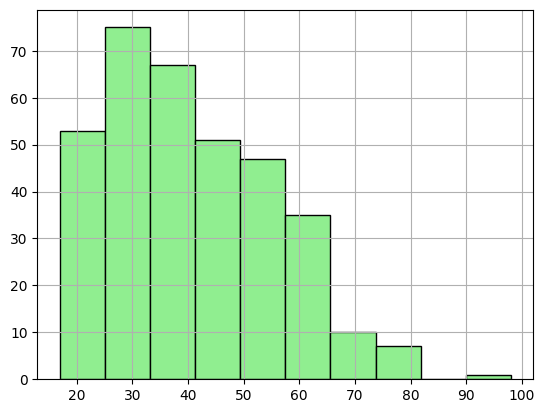

In [65]:
roubo_de_carros["Vict Age"].hist(
    color= "lightgreen",
    edgecolor= "black"
)